# Python Bootcamp Day 4

## Lecture 1: Multi-dimensional Data with Xarray (Continued)

### Lesson Goals
By the end of this lecture, you will be able to:
- Recall the core building blocks of xarray (Datasets, DataArrays, coordinates, dimensions) from yesterday's lesson
- Select and subset multi-dimensional data efficiently using `slice`
- Compute averages and sums across dimensions with `.mean()` and `.sum()`
- Use `.groupby()` to split data into groups (e.g., by season) and compute group-wise statistics
- Understand the difference between weighted and unweighted averages, and why it matters for unevenly-spaced time groups like months within a season
- Convert between xarray, numpy, and pandas data structures depending on the task at hand

### Outline
1. **Quick Review from Yesterday** — Datasets vs. DataArrays, indexing with `.isel()`
2. **2.4 Manipulating Multi-Dimensional Arrays**
   - `slice` and `mean`: selecting a time period and averaging over it
   - `groupby`: grouping data by season (DJF, MAM, JJA, SON)
   - Weighted vs. unweighted seasonal averages
3. **2.5 Xarray to NumPy** — converting DataArrays/Datasets to NumPy arrays
4. **2.6 Xarray to Pandas** — converting DataArrays to pandas Series/DataFrames

In [ ]:
# Mount the github repo to access data
from google.colab import drive
drive.mount('/content/drive')

# Path to shared bootcamp data (repo-root Datasets/)
DATA_FOLDER = "/content/drive/MyDrive/python_bootcamp/python_bootcamp_for_earth_science/Datasets/"

### Quick Review from Yesterday

In [3]:
# Path to shared bootcamp data (repo-root Datasets/)
DATA_FOLDER = "../../Datasets/"

Import the packages and libraries

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Read in the data using `open_dataset`

In [4]:
ds = xr.open_dataset(DATA_FOLDER + 'precip.mon.mean.nc')

In [5]:
ds # run this cell and click around below to get familiar with xarray dataset structure

<xarray.Dataset> Size: 21MB
Dimensions:  (time: 508, lat: 72, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
  * lat      (lat) float32 288B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    precip   (time, lat, lon) float32 21MB ...
Attributes:
    Conventions:    COARDS
    title:          CPC Merged Analysis of Precipitation (excludes NCEP Reana...
    platform:       Analyses
    source:         ftp ftp.cpc.ncep.noaa.gov precip/cmap/monthly
    dataset_title:  CPC Merged Analysis of Precipitation
    documentation:  https://www.esrl.noaa.gov/psd/data/gridded/data.cmap.html
    date_modified:  26 Feb 2019
    References:     https://www.psl.noaa.gov/data/gridded/data.cmap.html
    version:        V2105
    history:        update 05/2021 V2105
    data_modified:  2021-05-11

<font color="#0F766E">Question: What are the 4 different categories available in each `xarray` dataset?</font>

<font color="#0F766E">Question: What is the code below doing?</font>

In [11]:
ds['precip'].isel(lat=40).isel(lon=70)

<xarray.DataArray 'precip' (time: 508)> Size: 2kB
[508 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
    lat      float32 4B -11.25
    lon      float32 4B 176.2
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

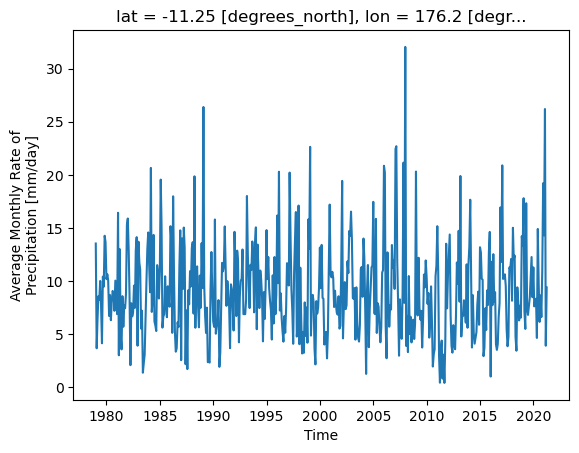

In [13]:
ds['precip'].isel(lat=40).isel(lon=70).plot()

Let's move on to the second half of the `xarray` lesson for today.

<font color="#0F766E">Question: What is the code below doing differently than the above?</font>

In [22]:
ds['precip'].sel(lat=-11.25, lon=176.25)

<xarray.DataArray 'precip' (time: 508)> Size: 2kB
[508 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
    lat      float32 4B -11.25
    lon      float32 4B 176.2
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

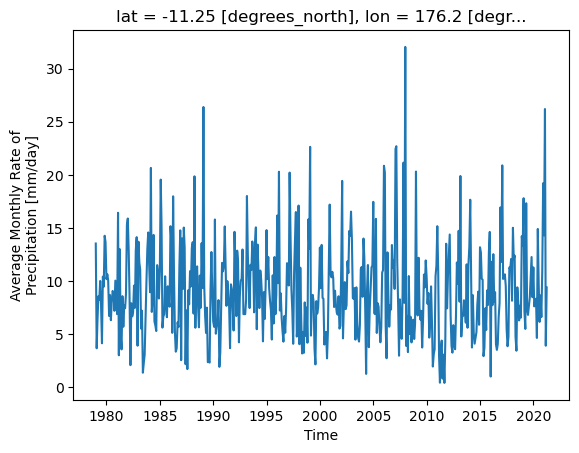

In [23]:
ds['precip'].sel(lat=-11.25, lon=176.25).plot()

<font color="#0F766E">Question: What is different here?</font>

In [24]:
ds['precip'].where((ds.lat>10) & (ds.lon<90))

<xarray.DataArray 'precip' (time: 508, lat: 72, lon: 144)> Size: 21MB
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.66, 0.69, 0.66, ...,  nan,  nan,  nan],
        [0.6 ,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.  , 0.  , 0.  , ...,  nan,  nan,  nan],
        [0.  ,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
...
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.  , 0.  , 0.  , ...,  nan,  nan,  nan],
        [0.  ,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.  , 0.  , 0.  , ...,  nan,  nan,  nan],
        [0.  ,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]],
      shape=(508, 72, 144), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
  * lat      (lat) float32 288B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

/opt/anaconda3/envs/pyleo/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/pyleo/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/pyleo/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/pyleo/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


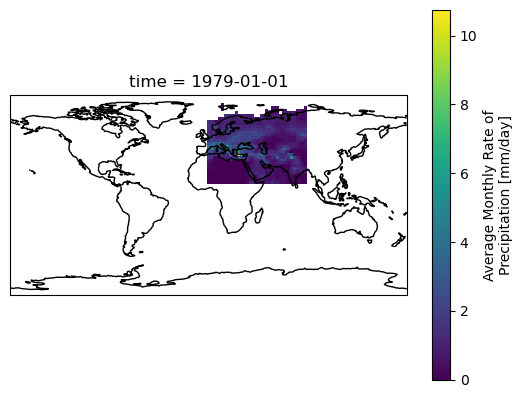

In [25]:
ax = plt.axes(projection=ccrs.PlateCarree())
ds['precip'].where((ds.lat>10) & (ds.lon<90)).isel(time=0).plot(transform=ccrs.PlateCarree())
ax.coastlines()
plt.show()

<font color="#0F766E">Question: What is different between these two approaches below?</font>

In [31]:
%%time
ds['precip'].where((ds.lat>10) & (ds.lon<90)).mean() # approach 1

CPU times: user 41.2 ms, sys: 8.42 ms, total: 49.6 ms
Wall time: 46.4 ms


<xarray.DataArray 'precip' ()> Size: 8B
array(1.08708501)

In [30]:
%%time
ds['precip'].where((ds.lat>10) & (ds.lon<90), drop=True).mean() # approach 2

CPU times: user 15.7 ms, sys: 5.19 ms, total: 20.9 ms
Wall time: 29.2 ms


<xarray.DataArray 'precip' ()> Size: 8B
array(1.08708501)

The `where` function applies a mask to the dataset. You can speed up the computation by dropping the NaNs in the dataset by toggling "drop" 

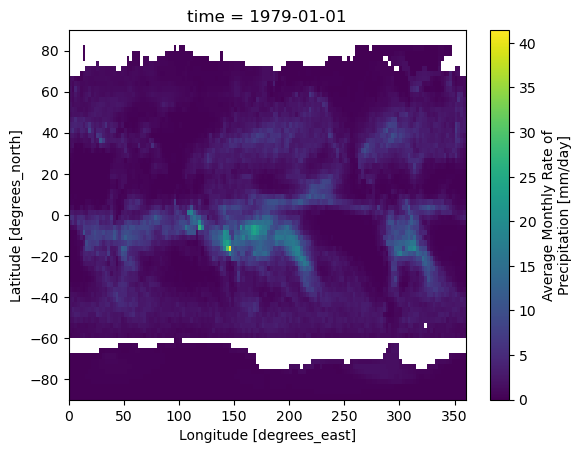

In [39]:
ds['precip'][0,:,:].plot()

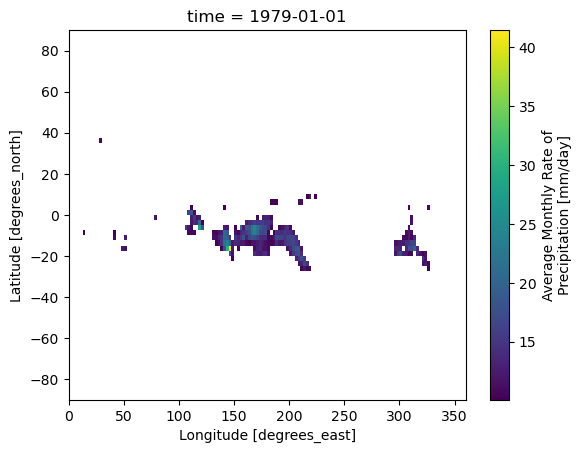

In [48]:
ds['precip'].where(ds.precip>20)[0,:,:].plot()

In [52]:
ds['precip'].where(ds.precip>20,drop=True).mean('time')

<xarray.DataArray 'precip' (lat: 34, lon: 136)> Size: 18kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(34, 136), dtype=float32)
Coordinates:
  * lat      (lat) float32 136B 61.25 58.75 56.25 38.75 ... -43.75 -61.25 -63.75
  * lon      (lon) float32 544B 6.25 8.75 11.25 13.75 ... 348.8 351.2 353.8

How has the dimensions of the dataset changed with this most recent masking based on precipitation amount?

### 2.4 Manipulating multi-dimensional arrays

Tools we will use:
* `slice`
* `mean`
* `sum`
* `groupby`

For more information on xarray tools: http://xarray.pydata.org/en/stable/user-guide/index.html
<br/>For more information on xarray indexing: http://xarray.pydata.org/en/stable/user-guide/indexing.html

For convenience, we will store the precipitation data as it's own data array.

Notice that we are sub-selecting an xarray DataArray from an xarray Dataset

In [101]:
precip = ds.precip
precip

<xarray.DataArray 'precip' (time: 508, lat: 72, lon: 144)> Size: 21MB
array([[[ nan,  nan, ...,  nan,  nan],
        [ nan,  nan, ...,  nan,  nan],
        ...,
        [0.06, 0.06, ..., 0.05, 0.05],
        [0.08, 0.07, ..., 0.08, 0.07]],

       [[ nan,  nan, ...,  nan,  nan],
        [0.66, 0.69, ..., 0.65, 0.66],
        ...,
        [0.01, 0.01, ..., 0.01, 0.01],
        [0.01, 0.01, ..., 0.01, 0.01]],

       ...,

       [[ nan,  nan, ...,  nan,  nan],
        [0.  , 0.  , ..., 0.  , 0.  ],
        ...,
        [0.  , 0.  , ..., 0.  , 0.  ],
        [0.  , 0.  , ..., 0.  , 0.  ]],

       [[ nan,  nan, ...,  nan,  nan],
        [0.  , 0.  , ..., 0.  , 0.  ],
        ...,
        [0.  , 0.  , ..., 0.  , 0.  ],
        [0.  , 0.  , ..., 0.  , 0.  ]]], shape=(508, 72, 144), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
  * lat      (lat) float32 288B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

### `slice` and `mean` Example 

We can use `slice` to select only a small portion of the data.

Why use `slice`? So that it is faster and easier to deal with. For instance, if you had 1 million data points for each year from the year 2010 - 2020 (so, total of 10 million data points), and you were only interested in the year 2004, you can use `slice` to select the year 2004 data to work on.

We can use `.mean` to average the data. Let's look at the average precipitation in 1995.

**Goal**: select 1995 dates, January to December, and take the mean over the dimension of `time`, then calculate and plot the result.

Let's do this step-by-step. The last line of the code cell below is a concise way of combining multiple operations in one line. Which do you prefer? And why?

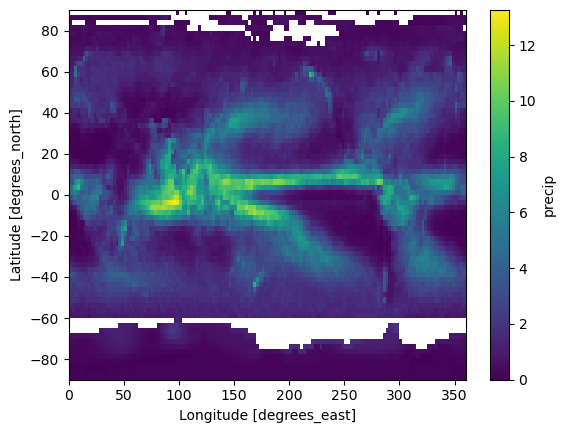

In [103]:
# Step 1: select the time slice for 1995 and store it in a new variable called `precip_1995`
precip_1995 = precip.sel(time=slice('1995-01-01','1995-12-01'))

# Step 2: take the mean over the dimension of `time` and store it in a new variable called `precip_1995_mean`
precip_1995_mean = precip_1995.mean(dim='time')

# Step 3: plot the mean precipitation for 1995 and store the plot in a variable called `precip_1995_plot`
precip_1995_plot = precip_1995_mean.plot()

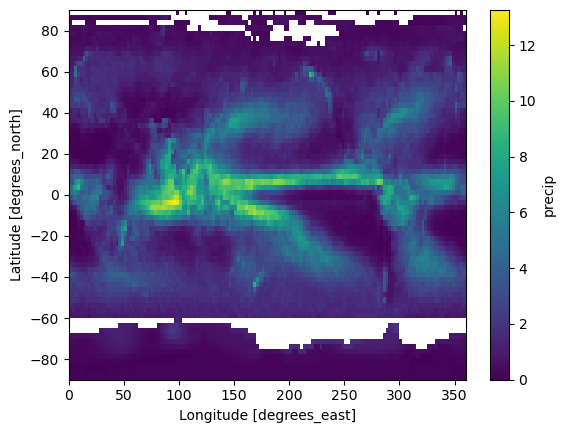

In [57]:
### alternative code that does the same thing but is more concise:
# notice how we can chain the operations together without needing to create intermediate variables
precip_1995_plot = precip.sel(time=slice('1995-01-01','1995-12-01')).mean(dim='time').plot()

### `groupby` Example 

`.groupby` is another useful tool. It allows us to split the data into multiple groups, work within these groups, and combine them back into a single dataset. Let's group time by season:

In [102]:
precip.groupby('time.season')

<DataArrayGroupBy, grouped over 1 grouper(s), 4 groups in total:
    'season': UniqueGrouper('season'), 4/4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'>

The data has been divided into four seasons: 

'DJF' for December-January-February (winter)

'JJA' for June-July-August (summer)

'MAM' for March-April-May (spring)

'SON' for September-October-November (fall). 

These are common shorthand notations used in Earth science.

Using `.sum`, we can sum over a given dimension. Combining groupby and sum, we can calculate the weighted seasonal averages. Let's just pick one year and one grid for simplicity. The equation below shows an example on how to calculate the weighted averaged preipitation for spring (MAM).

$$
P_{\text{spring}}
=
P_{\text{Mar}} \cdot \frac{31}{31+30+31}
+
P_{\text{Apr}} \cdot \frac{30}{31+30+31}
+
P_{\text{May}} \cdot \frac{31}{31+30+31}
$$

### Calculate the spring precipitation rate in 1995

Start by identifying the time period and location of interest.

We will now store this as a separate variable called `precip_example` and we will use Jan 1 -- Dec 31, 1995 as the time range. We will also select a grid point for this example.

In [60]:
# select the time slice for 1995, then select the latitude of 1.25 and longitude of 72, and store the result in a new variable called `precip_example`
# you can come back and change the latitude and longitude to see how the results change for different locations
precip_example = precip.sel(time=slice('1995-01-01','1995-12-31')).sel(lat=1.25).sel(lon=72, method='nearest')

View the example data

In [61]:
precip_example

<xarray.DataArray 'precip' (time: 12)> Size: 48B
array([9.39, 4.89, 2.87, 5.95, 6.67, 9.16, 4.17, 8.49, 9.12, 9.46, 4.14, 2.85],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1995-01-01 1995-02-01 ... 1995-12-01
    lat      float32 4B 1.25
    lon      float32 4B 71.25
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

<font color="#0F766E">Question: What is `nearest` doing here? Run the cell above and see what would happen if you removed it.</font>

In [62]:
# run this to show how longitude is stored in the dataset and why we need to use the `method='nearest'` argument in the previous cell
precip.lon

<xarray.DataArray 'lon' (lon: 144)> Size: 576B
array([  1.25,   3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
        23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,  43.75,
        46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,  63.75,  66.25,
        68.75,  71.25,  73.75,  76.25,  78.75,  81.25,  83.75,  86.25,  88.75,
        91.25,  93.75,  96.25,  98.75, 101.25, 103.75, 106.25, 108.75, 111.25,
       113.75, 116.25, 118.75, 121.25, 123.75, 126.25, 128.75, 131.25, 133.75,
       136.25, 138.75, 141.25, 143.75, 146.25, 148.75, 151.25, 153.75, 156.25,
       158.75, 161.25, 163.75, 166.25, 168.75, 171.25, 173.75, 176.25, 178.75,
       181.25, 183.75, 186.25, 188.75, 191.25, 193.75, 196.25, 198.75, 201.25,
       203.75, 206.25, 208.75, 211.25, 213.75, 216.25, 218.75, 221.25, 223.75,
       226.25, 228.75, 231.25, 233.75, 236.25, 238.75, 241.25, 243.75, 246.25,
       248.75, 251.25, 253.75, 256.25, 258.75, 261.25, 263.75, 266.25, 268.75,
       271.25, 273.75, 276.25, 278.75, 281.25, 283.75, 286.25, 288.75, 291.25,
       293.75, 296.25, 298.75, 301.25, 303.75, 306.25, 308.75, 311.25, 313.75,
       316.25, 318.75, 321.25, 323.75, 326.25, 328.75, 331.25, 333.75, 336.25,
       338.75, 341.25, 343.75, 346.25, 348.75, 351.25, 353.75, 356.25, 358.75],
      dtype=float32)
Coordinates:
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    units:          degrees_east
    long_name:      Longitude
    actual_range:   [  1.25 358.75]
    standard_name:  longitude
    axis:           X

Ensure that we have the right days per month and that all 12 months are present in the data

In [63]:
month_length = precip_example.time.dt.days_in_month
month_length

<xarray.DataArray 'days_in_month' (time: 12)> Size: 96B
array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
Coordinates:
  * time     (time) datetime64[ns] 96B 1995-01-01 1995-02-01 ... 1995-12-01
    lat      float32 4B 1.25
    lon      float32 4B 71.25
Attributes:
    long_name:      Time
    delta_t:        0000-01-00 00:00:00
    avg_period:     0000-01-00 00:00:00
    standard_name:  time
    axis:           T
    actual_range:   [1569072. 1939416.]

In [64]:
# Calculate the weights by grouping by 'time.season' since each month/season has a different number of days, we need to weight the average by the number of days in each month.
# In this case, we are calculating the weights for each month based on the number of days in that month. We then group by season and divide by the sum of days in that season to get the normalized weights.
weights = month_length.groupby('time.season') / month_length.groupby('time.season').sum()

# Calculate the weighted average by multiplying the original data by the weights and then summing over the 'time' dimension (instead of taking the mean). This will give us the weighted average precipitation for each season.
precip_weighted = (precip_example * weights).groupby('time.season').sum(dim='time')
precip_weighted

<xarray.DataArray (season: 4)> Size: 32B
array([5.73733338, 7.25282599, 5.15478253, 7.59406587])
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [65]:
# Compared with unweighted seasonal averages by directly taking the mean over the 'time' dimension after grouping by 'time.season'
precip_unweighted = precip_example.groupby('time.season').mean(dim='time')
precip_unweighted

<xarray.DataArray 'precip' (season: 4)> Size: 32B
array([5.71000051, 7.27333307, 5.16333342, 7.57333326])
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
    lat      float32 4B 1.25
    lon      float32 4B 71.25
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [ 0. 70.]
    units:         mm/day
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Merged Analysis of Precipitation Standard
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.   59.08]

<font color="#0F766E"> Calculate the sum of precipitation during the spring (over March, April, and May) of 1995. </font><br>
Remember, the equation is:
$$
P_{\text{spring}}
=
P_{\text{Mar}} \cdot \frac{31}{31+30+31}
+
P_{\text{Apr}} \cdot \frac{30}{31+30+31}
+
P_{\text{May}} \cdot \frac{31}{31+30+31}
$$

In [67]:
# Calculate the sum of precipitation over March, April, and May of 1995 using our example variable.
precip_spring_weighted = precip_weighted.sel(season='MAM')
precip_spring_unweighted = precip_unweighted.sel(season='MAM')

In [68]:
print('Spring 1995 precipitation rate (weighted):', precip_spring_weighted.values)
print('Spring 1995 precipitation rate (unweighted):', precip_spring_unweighted.values)

Spring 1995 precipitation rate (weighted): 5.15478253364563
Spring 1995 precipitation rate (unweighted): 5.163333415985107


<font color="#0F766E"> What are the units? </font><br>

Another `groupby` example - calculating anomalies  
In the geosciences, we typically think of anomalies as the value of something (e.g. precipitation)  
relative to the normal values for that time of year.  
Let's calculate anomalies of precipitation, where anomaly = value - normal values for that calendar month

In [71]:
precip_climatology = precip.sel(lat=1.25).sel(lon=72, method='nearest').groupby("time.month").mean()
precip_example_anom = precip_example.groupby("time.month") - precip_climatology
precip_example_anom

<xarray.DataArray 'precip' (time: 12)> Size: 96B
array([ 5.12953472,  2.43325567, -0.13488364,  0.53953505, -2.28952408,
        3.18142843, -1.85190439,  1.00500011,  1.04666615,  1.42190456,
       -2.35928583, -4.2904768 ])
Coordinates:
  * time     (time) datetime64[ns] 96B 1995-01-01 1995-02-01 ... 1995-12-01
    lat      (time) float32 48B 1.25 1.25 1.25 1.25 1.25 ... 1.25 1.25 1.25 1.25
    lon      (time) float32 48B 71.25 71.25 71.25 71.25 ... 71.25 71.25 71.25
    month    (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

### 2.5 Xarray to numpy

Once again, numpy is a powerful tool. Therefore, it is to our benefit to be able to convert xarray datasets to numpy arrays. 
<br/> We can do this with `np.array()`.

In [72]:
lat    = np.array(ds['lat'])
lon    = np.array(ds['lon'])
time   = np.array(ds['time'])
precip = np.array(ds['precip'])
lat

array([ 88.75,  86.25,  83.75,  81.25,  78.75,  76.25,  73.75,  71.25,
        68.75,  66.25,  63.75,  61.25,  58.75,  56.25,  53.75,  51.25,
        48.75,  46.25,  43.75,  41.25,  38.75,  36.25,  33.75,  31.25,
        28.75,  26.25,  23.75,  21.25,  18.75,  16.25,  13.75,  11.25,
         8.75,   6.25,   3.75,   1.25,  -1.25,  -3.75,  -6.25,  -8.75,
       -11.25, -13.75, -16.25, -18.75, -21.25, -23.75, -26.25, -28.75,
       -31.25, -33.75, -36.25, -38.75, -41.25, -43.75, -46.25, -48.75,
       -51.25, -53.75, -56.25, -58.75, -61.25, -63.75, -66.25, -68.75,
       -71.25, -73.75, -76.25, -78.75, -81.25, -83.75, -86.25, -88.75],
      dtype=float32)

As seen above, Xarray introduces labels on top of raw NumPy-like multidimensional arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. For example, with label names, you’ll easily understand what you were thinking when you come back to look at your code weeks or months later.

Notice also how numpy requires you to create an individual variable for each of the data categories while xarray allowed you to use a single dataset where all the data was self-contained.

Xarray also allows you to convert it to different formats using other ways.

<font color="#0F766E"> See what happens when you use `.values` and `.data` (Example: `ds['precip'].values`) </font><br>

In [73]:
ds['precip'].values

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [0.07, 0.08, 0.08, ..., 0.06, 0.06, 0.06],
        [0.06, 0.06, 0.06, ..., 0.05, 0.05, 0.05],
        [0.08, 0.07, 0.07, ..., 0.08, 0.08, 0.07]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.66, 0.69, 0.66, ..., 0.63, 0.65, 0.66],
        [0.6 ,  nan,  nan, ..., 0.57, 0.57, 0.57],
        ...,
        [0.01, 0.01, 0.01, ..., 0.  , 0.  , 0.  ],
        [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
        [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  ,  nan,  nan, ..., 0.  , 0.  , 0.  ],
        ...,
        [0.02, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
        [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.04],
        [0.1 , 0.1 , 0.1 , ..., 0.1 , 0.1 , 0.09]],

       ...,

       [[ nan,  nan,  na

### 2.6 Xarray to pandas

Xarray and pandas objects are also interchangeable. A shortcut to convert a dataArray directly into a pandas object is  `DataArray.to_pandas()` (i.e., a 1D array is converted to a `Series`, 2D to `DataFrame` and 3D to `Panel`).

We would like to save the global average rainfall into an excel file. However, before we calculate the global average, we must weight the data by latitude

In [78]:
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"
weights
weighted_precip = ds.weighted(weights)
weighted_mean = weighted_precip.mean(("lon","lat"))

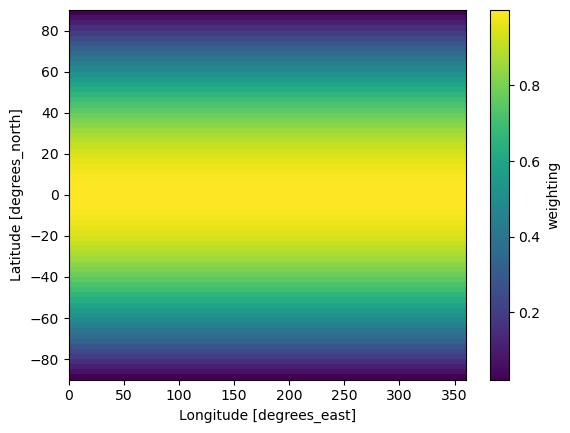

In [104]:
#this visualizes the weighting effect as a function of latitude
(weights*ds.lon.where(ds.lon>360,1)).plot(cbar_kwargs={"label":"weighting"})

Now let's compare the timeseries of the weighted global average to an unweighthed average (variable called "unweighted_mean"). 

Calculate a timeseries of the global average rainfall using the `mean` function. Then plot both timeseries.

How different are they?

In [ ]:
#your code goes here

Convert these two timeseries into pandas dataframes, which we can then use to export as excel files or CSVs.

In [92]:
unweighted_mean_df = unweighted_mean.to_pandas()
weighted_mean_df = weighted_mean.to_pandas()

In [98]:
weighted_mean_df=weighted_mean_df.rename(columns={"precip":"precip_weighted"})
weighted_mean_df["precip_unweighted"]=unweighted_mean_df.precip

In [ ]:
weighted_mean_df

Now you can export this dataframe to excel using `to_excel`

Xarray is heavily inspired by pandas, which also works with labeled arrays, and it uses pandas internally. The main distinguishing feature of xarray's dataarray over labeled arrays in pandas is that dimensions can have names (e.g. "time", "latitude"), which are easier to keep track of than axis numbers. While pandas is a great tool for working with tabular data, it can get a little awkward when data is of higher dimension (See more at https://docs.xarray.dev/en/stable/).